In [1]:
import os 
from dotenv import load_dotenv
load_dotenv()

True

In [2]:
from langgraph.graph import MessagesState

class AgentState(MessagesState):
    input: str


In [3]:
import chromadb

client = chromadb.PersistentClient(path="data/chroma")
collection = client.get_collection(
    name="parcel_pilot_docs"
)

def search_docs(query: str, k: int = 3) -> list[dict]:
    results = collection.query(
        query_texts=[query],
        n_results=k
    )

    documents = results["documents"][0]
    metadatas = results["metadatas"][0]
    distances = results["distances"][0]

    return [
        {
            "text": document,
            "metadata": metadata,
            "distance": distance 
        }
        for document, metadata, distance in zip(documents, metadatas, distances)
    ]

In [4]:
results = search_docs(
    "What happens if a customer cancels their order?"
)

print(results)

[{'text': 'Document: 03_Cancellation_and_Service_Credit_SOP_v4.pdf\nSection: 1. Order cancellation\n\n●\u200b DRAFT: May be cancelled with no fee.\n  ●\u200b BOOKED, not yet PICKED_UP: May be cancelled. No fee within 30 minutes of booking. After 30 minutes,\n     charge INR 250 unless a customer agreement explicitly waives the cancellation fee.\n  ●\u200b PICKED_UP: Do not cancel. Use the return-to-origin workflow if the customer wants the parcel returned.\n  ●\u200b DELIVERED: Cannot be cancelled.', 'metadata': {'section': '1. Order cancellation', 'source': '03_Cancellation_and_Service_Credit_SOP_v4.pdf'}, 'distance': 0.20901453495025635}, {'text': 'Document: 05_Northstar_Logistics_Enterprise_Agreement.pdf\nSection: 2. Shipment cancellation\n\nNorthstar may cancel any BOOKED shipment before pickup with no cancellation fee, regardless of how long ago the\nshipment was booked. Once a shipment is PICKED_UP, the standard return-to-origin process applies.', 'metadata': {'source': '05_North

In [5]:
from langchain.tools import tool 

@tool
def search_docs_tool(query: str) -> str:
    """
    Search the Parcel Pilot documentation for information relevant
    to the user's question.

    Use this tool whenever the answer requires information from
    the internal documentation.
    """

    results = search_docs(query, k=3)

    if not results:
        return "No relevant documentation was found."

    formatted_results = []

    for i, result in enumerate(results, start=1):
        metadata = result["metadata"]
        source = metadata.get("source", "Unknown")
        section = metadata.get("section")
        page = metadata.get("page")

        location = section or (
            f"Page {page}" if page is not None else "Unknown location"
        )

        formatted_results.append(
            f"""
            Result {i}
            Source: {source}
            Location: {location}

            {result['text']}
            """
        )

        return "\n\n".join(formatted_results)

In [6]:
all_tools = [search_docs_tool]


In [8]:
from langchain_google_genai import ChatGoogleGenerativeAI

model = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
)
llm = model.bind_tools(all_tools)

In [20]:
from langgraph.graph import END
from langgraph.types import Command, interrupt
from langchain_core.messages import HumanMessage

def human_node(state: AgentState):
    human_input = interrupt("Please enter your input: ")

    if human_input.strip().lower() == 'exit':
        next_node = END 
    else: 
        next_node = "agent"
    
    return Command (
        update={
            "messages": [HumanMessage(content=human_input, name="human")]
        },
        goto=next_node
    )

In [21]:
from langchain_core.messages import AIMessage, SystemMessage 

def agent_node(state: AgentState):
    message_history = state.get('messages', [])

    messages = [
        SystemMessage(content="You are a helpful assistant that can answer questions by retrieving information from search docs tool. DO NOT ASSUME ANYTHING AND ONLY USE THE tool for any information."),
    ] + message_history 

    response = llm.invoke(messages)

    return {
        "messages": [response]
    }



In [22]:
from langgraph.graph import StateGraph
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.checkpoint.memory import InMemorySaver

builder = StateGraph(AgentState) 
builder.add_node("human", human_node)
builder.add_node("agent", agent_node)
builder.add_node("tools", ToolNode(all_tools))
builder.set_entry_point("agent")

builder.add_conditional_edges("agent", tools_condition, {"tools": "tools", "__end__": "human"})
builder.add_edge("tools", "agent")

graph = builder.compile(checkpointer=InMemorySaver())

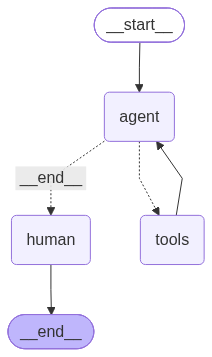

In [23]:
from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [24]:
input = {
    "messages": [HumanMessage(content="Tell me about the serverity definitions of the current support policy.")]
}
config = {"configurable": {"thread_id": "123"}}

output = graph.invoke(input, config)

In [26]:
output['messages'][-1].content

[{'type': 'text',
  'text': 'The current support policy defines the following severity levels:\n\n*   **P1 - Critical:** This indicates a complete production outage preventing all shipment creation for a customer, a confirmed security incident or suspected credential exposure, or another event causing immediate material business risk with no workaround.\n*   **P2 - High:** This refers to a major feature being unavailable or materially degraded for a customer, but core operations remain possible or a workaround exists.\n*   **P3 - Normal:** This covers minor defects, how-to questions, configuration requests, or issues with limited operational impact.',
  'extras': {'signature': 'Ct8CARFNMg8ur8ahjWeQeDhq5ZDDyXfGNQtN+R3L70AMMUVrDYmmBx+qZkA28cZ/u6P5s8nLahvEPU4p1ear6cfd8Xuxn4E0SQxdV9aeFsaCcjGweZKxR4rjSxKYfHs/6eiOaTPznF65SkPpQ5IdtlHffjCA8f5GEU78sgzjDwLRVu6/UjMJTbsEuQxQxK98VvCuyJ6ysrapgQUsBnoP4gfAglJMCk8Bk2zWfWME4Syrv+SpCbJVCq5IBdHDwLqCTMH+2W4Seh6CotbMTD/cwCPvEJLkCs6aJ0ra0ddRifLCoflqXJYDXvhP+

#### Tools